1. Use Codebook to check the meanings for different columns.
2. I only involve questions for two independent groups here (because I feel like that is the easiest way to accomplish the project?), but actually there are many interesting questions we can ask. If you have thoughts for other types of questions, please share them:)

In [1]:
library(readr)
library(tidyverse)
MIUDS_2 <-
    read_tsv("04652-0001-Data.tsv")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ purrr     1.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 4963 Columns: 2189
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr    (1): B1PSOC
dbl (2188): M2ID, M2FAMNUM, SAMPLMAJ, B1STATUS, B1PAGE_M2, B1PRAGE_2019, M2A...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [2]:
head(MIUDS_2)

M2ID,M2FAMNUM,SAMPLMAJ,B1STATUS,B1PAGE_M2,B1PRAGE_2019,M2AGE_FLAG,B1PBYEAR,B1PBYEAR_2019,M2BYEAR_FLAG,⋯,B1SP3I,B1SP3J,B1SP4,B1SP5,B1SQ1,B1SQ2,B1SQ3,B1SQ4,B1SQ5,B1SQ6
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10001,110498,2,2,61,61,0,1943,1943,0,⋯,8,8,8,8,8,5,7,8,8,8
10002,100001,1,2,69,69,0,1935,1935,0,⋯,8,8,8,8,9,9,9,7,6,10
10005,120803,3,2,80,80,0,1924,1924,0,⋯,8,8,8,8,10,10,10,10,10,10
10006,120772,3,1,60,60,0,1944,1944,0,⋯,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
10010,120378,3,2,55,55,0,1948,1948,0,⋯,2,2,3,3,8,8,8,9,9,9
10011,110475,2,2,52,52,0,1952,1952,0,⋯,2,1,4,4,8,10,9,9,10,8


Current_employment,Workday_sleep_hours
<dbl>,<dbl>
2,8
1,7
2,7
2,-1
1,6
2,8


[1] 4946    2

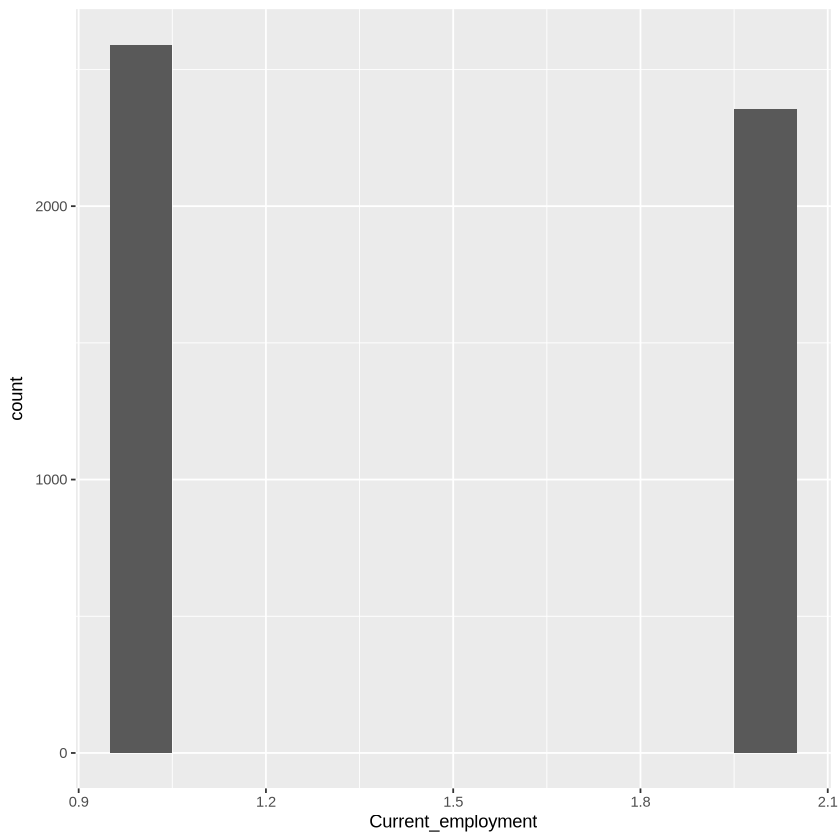

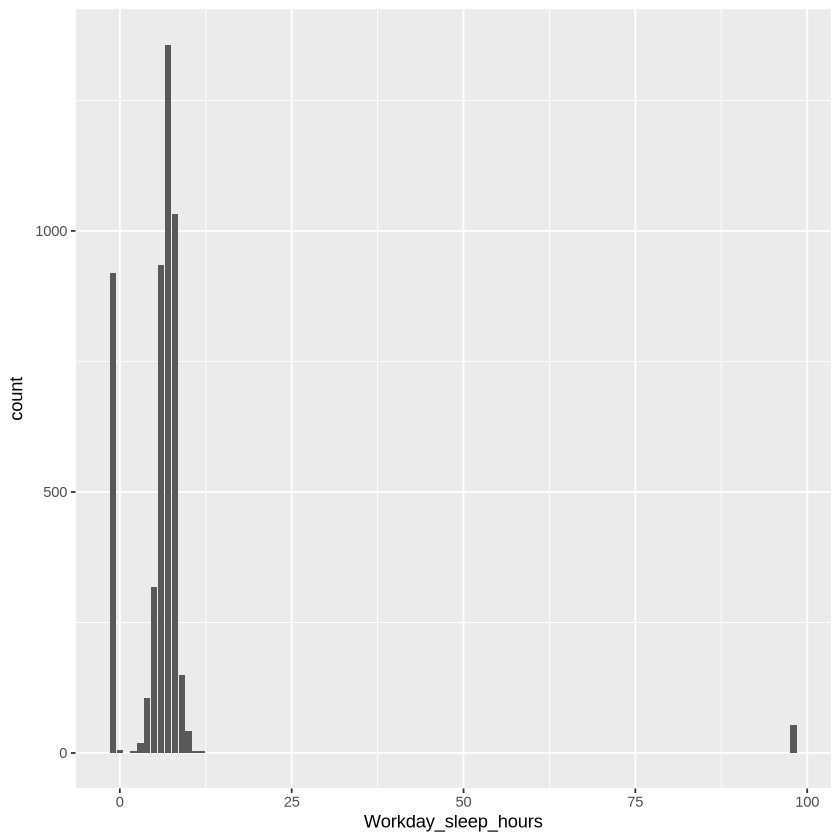

In [5]:
# Q1: Does employment status directly impact workday sleep duration?
# CHECK: 
# B1PB3A -> Current employment - Working
## 1-Yes, 2-No, 7-Don't know, 9-Inapplicable. We only care about 0 and 1 here.
# B1SA57A -> Hours of sleep on workdays
# Alternative: B1SA57B -> Minutes of sleep on workdays(but I think that data in B1SA57A are more ideal?)
MIUDS_2_sleep_hours <- MIUDS_2 |>
                    select(B1PB3A, B1SA57A) |>
                    rename(
                        Current_employment = B1PB3A,
                        Workday_sleep_hours = B1SA57A) |>
                    filter(Current_employment %in% c(1,2)) # Ignore 7 and 9.
head(MIUDS_2_sleep_hours)
dim(MIUDS_2_sleep_hours)

Current_employment_plot <- MIUDS_2_sleep_hours |>
            ggplot() +
            geom_bar(aes(x = Current_employment), width = 0.1)
Current_employment_plot

sleep_hours_plot <- MIUDS_2_sleep_hours |>
                    ggplot() +
                    geom_bar(aes(x = Workday_sleep_hours))
sleep_hours_plot


Sex,Self_Reported_Physical_Health
<dbl>,<dbl>
1,4
1,1
2,2
2,3
1,2
2,1


[1] 4963    2

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


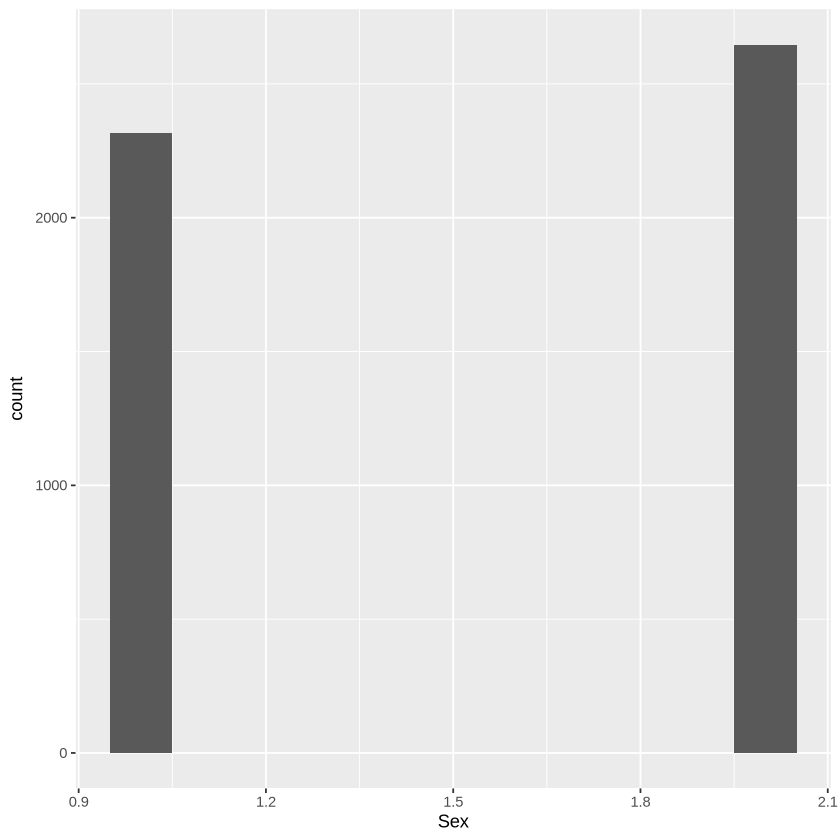

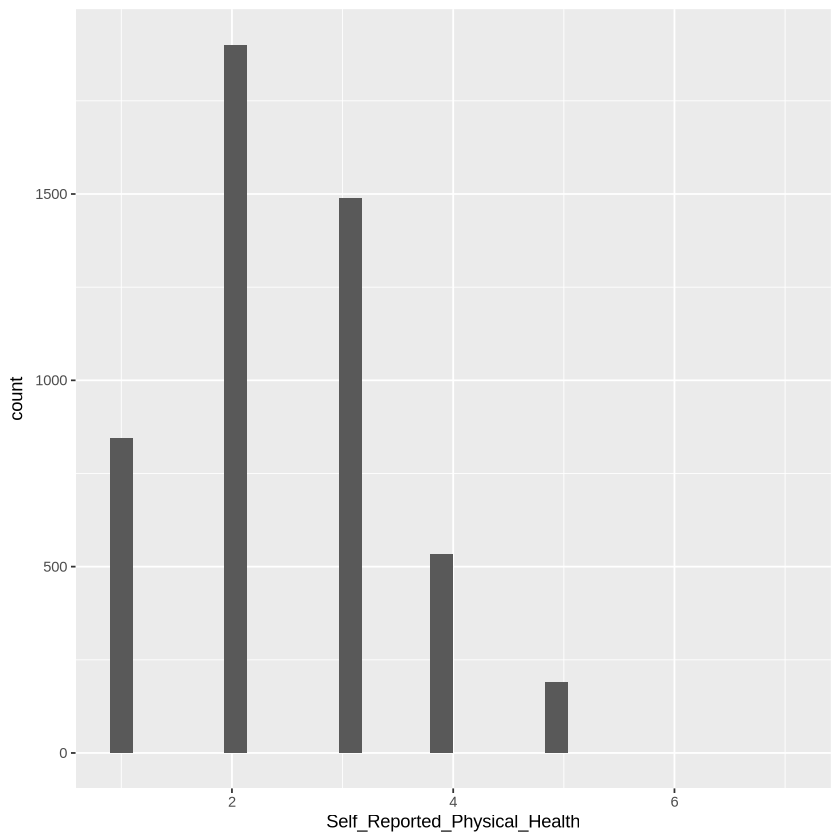

In [8]:
# Q2: Is there a statistically significant difference in self-reported physical health between males and females? 
# CHECK: 
# B1PRSEX -> Respondent's sex
## 1-Male, 2-Female
# B1PA1 -> Physical health self-evaluated
## Alternatives: B1PA2 -> Mental/emotional health self-evaluated
### According to the dataset, this variable is actually categorical. 
### But it also makes sense if we say the mean of physical health score is a value in between the integers.
### So if we want to solve this question, we may treat them as continuous.
### But I'm not sure if that's the most ideal way to use the data:)
MIUDS_2_sex_and_physical <- MIUDS_2 |>
                    select(B1PRSEX, B1PA1) |>
                    rename(
                        Sex = B1PRSEX,
                        Self_Reported_Physical_Health = B1PA1)
head(MIUDS_2_sex_and_physical)
dim(MIUDS_2_sex_and_physical)

Sex_plot <- MIUDS_2_sex_and_physical |>
            ggplot() +
            geom_bar(aes(x = Sex), width = 0.1)
Sex_plot

Physical_health_plot <- MIUDS_2_sex_and_physical |>
                        ggplot() +
                        geom_histogram(aes(x = Self_Reported_Physical_Health))
Physical_health_plot

Highest_degree,First_work_age,College_or_not
<dbl>,<dbl>,<chr>
9,21,College_Degree
12,14,College_Degree
3,35,No_College_Degree
6,15,No_College_Degree
5,11,No_College_Degree
11,18,College_Degree


[1] 4956    3

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


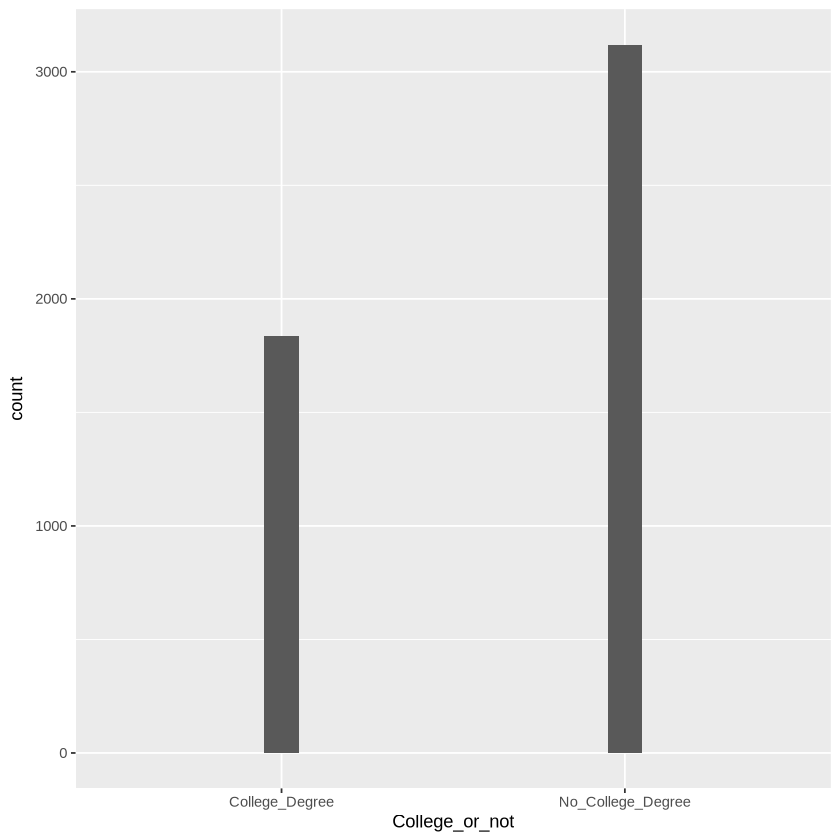

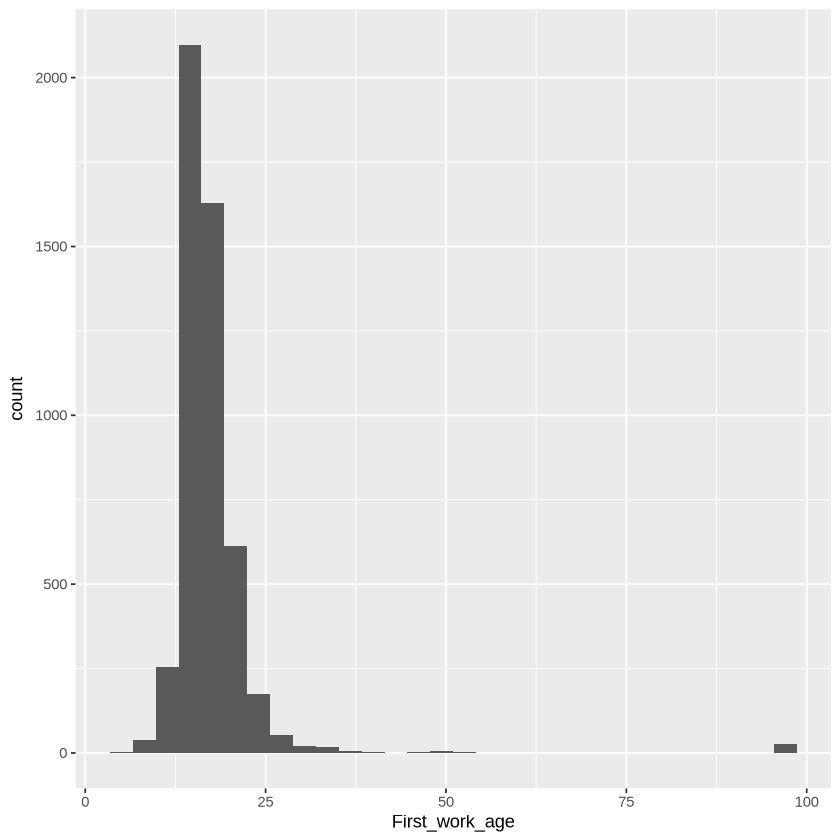

In [11]:
# Q3: Is there a statistically significant difference in the mean age of entering the long-term workforce 
# between individuals with a four-year college degree or higher and those without a four-year college degree?
# CHECK: 
# B1PB1 -> Highest level of education completed
## There are 12 levels (except 97-Don't know), here I categorize them into 2 new levels.
# B1PB2 -> Age first worked for pay for 6 or more months
## According to the dataset, this variable is actually categorical. 
## But it also makes sense if we say the mean age is a decimal.
## So if we want to solve this question, we may treat them as continuous.
## But I'm not sure if that's the most ideal way to use the data:)
MIUDS_2_degree_and_work <- MIUDS_2 |>
                           select(B1PB1, B1PB2) |>
                           rename(
                               Highest_degree = B1PB1,
                               First_work_age = B1PB2) |>
                           filter(Highest_degree != 97) |> # Ignore 97.
                           mutate(
                               College_or_not = ifelse(Highest_degree %in% c(9,10,11,12), "College_Degree", "No_College_Degree"))
head(MIUDS_2_degree_and_work)
dim(MIUDS_2_degree_and_work)

College_or_not_plot <- MIUDS_2_degree_and_work |>
                       ggplot() +
                       geom_bar(aes(x = College_or_not), width = 0.1)
College_or_not_plot

First_work_age_plot <- MIUDS_2_degree_and_work |>
                       ggplot() +
                       geom_histogram(aes(x = First_work_age))
First_work_age_plot